# Disaster Tweets — CV Ensemble with Single/Few RoBERTa Runs


This is a less expensive F1-focused version. It keeps one fixed 80/20 validation split for RoBERTa, but improves the two cheaper model families with fold-averaging. It then tunes ensemble weights and threshold on the shared validation set.

Compared with the full notebook, this trains RoBERTa **once by default for validation** and optionally a second time on all labeled data for stronger test predictions. This is much cheaper than five RoBERTa folds, which was our initial plan. After running the full model, the results ended up worse than this approach.

Based on this we decided to upload this notebook as Guideline & Reference / Justification for our best score.

## 0. Brief Introduction

This notebook serves as an alternative final step for the submission of our **Disaster tweets classification project**. It combines the predictions from three different models: a Logistic Regression, a Transformer-based model, and a RoBERTa-base model.

These models were not chosen at random; they represent the best options from classical baseline and deep models coming from the respective highest F1 scores our local LLM agent provided.

Our approach to the challenge came from the project proposed for the CLSBE class Advanced Topics in Predictive Analytics, where we:
1) built an **AI-powered autonomous research agent** that designed, trained, evaluated, and iterated over deep learning models - without human intervention.
2) tuned and tested several **locally hosted Large Language Models** as its “brain” to drive the machine learning experimentation. -- our final model for the iterations was *gemma4*.

The core of the project focused on these goals. However, as we dug deeper into the competition for *NLP with Disaster Tweets* we became aware of the pre-trained transformer encoder models that could be used to better identify target tweets.

By researching these models we found out they could not be fully implemented within our locally run LLM's constraints (in our case, gemma /qwen), mainly because of limited computing power and the 1-hour execution limit for the autonomous agent. We did however test the best model we could outside the agent loop, based on our restrictions. We decided to run **RoBERTa** as it was our best option to achieve a higher F1 score with the limitations we had. This model, as expected, outperformed the ones our locally hosted LLM suggested.

Therefore, as a final solution to the challenge, we decided to:
1) from our locally hosted LLM, with all its prompts, conditions and iterations, select the **two** model architectures that returned a higher F1 Classifier score;
2) create an **Ensemble** of the *RoBERTa* model with our local LLM suggestions (*CountVec + LogReg*, and *Keras Embedding + Transformer*);
3) add a cheaper cross-validation approach for the local LLM models, using stratified folds to make the validation process more robust without requiring the full computational cost of running RoBERTa across all folds.

This notebook is therefore a less expensive version of the final ensemble approach. Instead of running the full 5-fold cross-validation process for every model, it applies cross-validation mainly to the cheaper components while keeping RoBERTa as the strongest pre-trained model in the ensemble. This allowed us to improve the reliability of the ensemble while keeping the runtime manageable.

The ensemble approach is used to leverage the strengths of each individual model, aiming to improve overall performance on the validation set and ultimately on the test set for submission.




*note: the model tuning present in the notebook is based on the suggested architecture by our locally hosted LLM (gemma4), with our tested and tuned prompts. The cross-validation added in this notebook was used as a practical improvement to increase F1 while keeping computational cost lower than the full RoBERTa 5-fold version.*

Sincerely, the team.

Francisca Nunes, Lourenço Sarmento, Tiago Ferreira, José Lopes.

In [1]:
import os, sys, random, gc, json, time
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import torch
import keras
from keras import layers

try:
    import keras_hub as keras_nlp
except ImportError:
    import keras_nlp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

cuda_ok = torch.cuda.is_available()
mps_ok = torch.backends.mps.is_available()
DEVICE = "cuda" if cuda_ok else ("mps" if mps_ok else "cpu")

print("Keras:", keras.__version__)
print("Torch:", torch.__version__)
print("Device:", DEVICE)


Keras: 3.14.1
Torch: 2.12.0
Device: mps


## 1. Load data and keep one shared validation split

This preserves the structure of the original notebook, so RoBERTa only needs a single validation run.


In [2]:
DATA_DIR = "../data"
SUBMISSION_DIR = "../submission-files"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

X_train, X_val, y_train, y_val = train_test_split(
    df_train["text"].astype(str),
    df_train["target"].astype(int),
    test_size=0.20,
    random_state=SEED,
    stratify=df_train["target"],
)
X_test = df_test["text"].astype(str)

X_train_np = X_train.values
X_val_np = X_val.values
y_train_np = y_train.values
y_val_np = y_val.values
X_test_np = X_test.values

print(len(X_train), "train /", len(X_val), "val /", len(X_test), "test")


6090 train / 1523 val / 3263 test


## 2. Helpers and model builders


In [3]:
def cleanup_memory():
    """Free memory between folds/models."""
    try:
        keras.backend.clear_session()
    except Exception:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


def softmax2(logits):
    """Convert 2-class logits to P(class=1)."""
    logits = np.asarray(logits)
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return (e / e.sum(axis=1, keepdims=True))[:, 1]


def best_threshold_f1(y_true, probs, low=0.20, high=0.80, steps=121):
    """Find the threshold that maximizes F1 for one probability vector."""
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    best_f1, best_t = -1.0, 0.5
    for t in np.linspace(low, high, steps):
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_f1, best_t


def display_confusion_matrix(y_true, probs_or_pred, title, threshold=None):
    """Display confusion matrix. If probabilities are passed, threshold is used."""
    arr = np.asarray(probs_or_pred)
    if arr.ndim == 2:
        y_pred = np.argmax(arr, axis=1)
    elif threshold is not None:
        y_pred = (arr >= threshold).astype(int)
    else:
        y_pred = arr.astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Not Disaster", "Disaster"],
        cmap=plt.cm.Blues,
    )
    disp.ax_.set_title(f"{title} — F1: {f1:.4f}")
    plt.show()
    return f1


def plot_roc(y_true, probs, name):
    auc = roc_auc_score(y_true, probs)
    fig, ax = plt.subplots(figsize=(5, 5))
    RocCurveDisplay.from_predictions(y_true, probs, name=name, ax=ax)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"{name} ROC — AUC = {auc:.4f}")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return auc


def build_logreg():
    """Agent's best classical model."""
    return Pipeline([
        ("vec", CountVectorizer(ngram_range=(1, 3), min_df=2, max_features=30000)),
        ("clf", LogisticRegression(
            C=1.0,
            max_iter=2000,
            class_weight="balanced",
            solver="liblinear",
            random_state=SEED,
        )),
    ])


VOCAB_SIZE = 20000
MAX_LEN = 100
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
TF_BS = 32
TF_LR = 3e-4
TF_EPOCHS = 10


def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
    )(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + ff)


def build_transformer():
    inp = keras.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inp)
    x = layers.Dropout(0.1)(x)
    x = transformer_block(x, EMBED_DIM, NUM_HEADS, FF_DIM)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(TF_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


ROBERTA_BS = 32
ROBERTA_EPOCHS = 3
ROBERTA_SEQUENCE_LENGTH = 160
ROBERTA_LR = 1e-5
ROBERTA_WEIGHT_DECAY = 0.01
ROBERTA_CLASS_WEIGHT = {0: 1.0, 1: 1.4}


def build_roberta():
    preprocessor = keras_nlp.models.RobertaPreprocessor.from_preset(
        "roberta_base_en",
        sequence_length=ROBERTA_SEQUENCE_LENGTH,
        name=None,
    )
    model = keras_nlp.models.RobertaClassifier.from_preset(
        "roberta_base_en",
        preprocessor=preprocessor,
        num_classes=2,
    )
    model.to(DEVICE)
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.AdamW(ROBERTA_LR, weight_decay=ROBERTA_WEIGHT_DECAY),
        metrics=["accuracy"],
    )
    return model


def search_weighted_ensemble(y_true, prob_dict, weight_step=0.025, threshold_low=0.20, threshold_high=0.80, threshold_steps=121):
    """Grid-search soft-voting weights and threshold for exactly 3 model probability vectors."""
    names = list(prob_dict.keys())
    assert len(names) == 3, "This helper expects exactly three probability vectors."
    p0, p1, p2 = [np.asarray(prob_dict[n]) for n in names]
    thresholds = np.linspace(threshold_low, threshold_high, threshold_steps)

    best = {"f1": -1.0}
    weight_values = np.arange(0.0, 1.0 + weight_step / 2, weight_step)
    for w0 in weight_values:
        for w1 in weight_values:
            w2 = 1.0 - w0 - w1
            if w2 < -1e-9:
                continue
            combo = w0 * p0 + w1 * p1 + w2 * p2
            for t in thresholds:
                f1 = f1_score(y_true, (combo >= t).astype(int), zero_division=0)
                if f1 > best["f1"]:
                    best = {
                        "type": "weighted_soft_vote",
                        "f1": float(f1),
                        "threshold": float(t),
                        "weights": {names[0]: float(w0), names[1]: float(w1), names[2]: float(w2)},
                    }
    return best


def search_stacking_ensemble(y_true, train_matrix, test_matrix=None):
    """Train a tiny logistic-regression stacker over model probabilities and tune threshold."""
    Cs = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
    class_weights = [None, "balanced"]
    best = {"f1": -1.0}
    best_model = None

    for C in Cs:
        for cw in class_weights:
            meta = LogisticRegression(
                C=C,
                class_weight=cw,
                solver="liblinear",
                max_iter=2000,
                random_state=SEED,
            )
            meta.fit(train_matrix, y_true)
            meta_probs = meta.predict_proba(train_matrix)[:, 1]
            f1, t = best_threshold_f1(y_true, meta_probs)
            if f1 > best["f1"]:
                best = {
                    "type": "logistic_stacking",
                    "f1": float(f1),
                    "threshold": float(t),
                    "C": C,
                    "class_weight": cw,
                    "train_probs": meta_probs,
                }
                best_model = meta

    if test_matrix is not None:
        best["test_probs"] = best_model.predict_proba(test_matrix)[:, 1]
    best["model"] = best_model
    return best


## 3. Fold-average the cheap models

For LogReg and the Keras Transformer, this trains 5 fold models on the training split and averages their predictions on the shared validation and test sets. It then trains one additional full-training model for each family and blends it with the fold average. This usually gives a stronger and more stable signal than a single cheap model.


In [4]:
N_CHEAP_FOLDS = 5
skf = StratifiedKFold(n_splits=N_CHEAP_FOLDS, shuffle=True, random_state=SEED)

val_logreg_cv = np.zeros(len(X_val_np))
test_logreg_cv = np.zeros(len(X_test_np))
val_transformer_cv = np.zeros(len(X_val_np))
test_transformer_cv = np.zeros(len(X_test_np))

cheap_fold_scores = []

for fold, (tr_idx, _) in enumerate(skf.split(X_train_np, y_train_np), 1):
    print("\n" + "=" * 80)
    print(f"Cheap fold {fold}/{N_CHEAP_FOLDS}")
    print("=" * 80)

    X_tr = X_train_np[tr_idx]
    y_tr = y_train_np[tr_idx]

    # CountVec + LogReg
    logreg = build_logreg()
    logreg.fit(X_tr, y_tr)
    val_logreg_cv += logreg.predict_proba(X_val_np)[:, 1] / N_CHEAP_FOLDS
    test_logreg_cv += logreg.predict_proba(X_test_np)[:, 1] / N_CHEAP_FOLDS

    # Keras Transformer
    text_vectorizer = layers.TextVectorization(
        max_tokens=VOCAB_SIZE,
        output_sequence_length=MAX_LEN,
        standardize="lower_and_strip_punctuation",
    )
    text_vectorizer.adapt(X_tr)

    X_tr_vec = text_vectorizer(X_tr)
    X_val_vec = text_vectorizer(X_val_np)
    X_test_vec = text_vectorizer(X_test_np)

    tf_model = build_transformer()
    tf_model.fit(
        X_tr_vec,
        y_tr,
        validation_data=(X_val_vec, y_val_np),
        batch_size=TF_BS,
        epochs=TF_EPOCHS,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        )],
        verbose=1,
    )

    val_transformer_cv += tf_model.predict(X_val_vec, batch_size=TF_BS * 2, verbose=0).flatten() / N_CHEAP_FOLDS
    test_transformer_cv += tf_model.predict(X_test_vec, batch_size=TF_BS * 2, verbose=0).flatten() / N_CHEAP_FOLDS

    cheap_fold_scores.append({
        "fold": fold,
        "logreg_val_f1_running": best_threshold_f1(y_val_np, val_logreg_cv * N_CHEAP_FOLDS / fold)[0],
        "transformer_val_f1_running": best_threshold_f1(y_val_np, val_transformer_cv * N_CHEAP_FOLDS / fold)[0],
    })

    del logreg, tf_model, text_vectorizer, X_tr_vec, X_val_vec, X_test_vec
    cleanup_memory()

pd.DataFrame(cheap_fold_scores)



Cheap fold 1/5
Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.5425 - loss: 0.7033 - val_accuracy: 0.5706 - val_loss: 0.6765
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6143 - loss: 0.6547 - val_accuracy: 0.7551 - val_loss: 0.5821
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7847 - loss: 0.4844 - val_accuracy: 0.7958 - val_loss: 0.4609
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9044 - loss: 0.2592 - val_accuracy: 0.7617 - val_loss: 0.5287
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9503 - loss: 0.1359 - val_accuracy: 0.7879 - val_loss: 0.5502

Cheap fold 2/5
Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5441 - loss: 0.7236 - val_accuracy: 0.5706 - val_loss: 0.6734
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6049 - loss: 0.6675 - val_accuracy: 0.6408 - val_loss: 0.6082
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 

,fold,logreg_val_f1_running,transformer_val_f1_running
0,1,0.763177,0.766234
1,2,0.774487,0.770079
2,3,0.775849,0.771010
3,4,0.776235,0.771642
4,5,0.777259,0.776296


In [5]:
# Add one full-training model for each cheap family, then blend full and CV predictions.
# The blend weight is tuned on the shared validation split, because F1 is the only objective here.

# Full LogReg
logreg_full = build_logreg()
logreg_full.fit(X_train_np, y_train_np)
val_logreg_full = logreg_full.predict_proba(X_val_np)[:, 1]
test_logreg_full = logreg_full.predict_proba(X_test_np)[:, 1]

# Full Keras Transformer
text_vectorizer_full = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize="lower_and_strip_punctuation",
)
text_vectorizer_full.adapt(X_train_np)

X_train_vec_full = text_vectorizer_full(X_train_np)
X_val_vec_full = text_vectorizer_full(X_val_np)
X_test_vec_full = text_vectorizer_full(X_test_np)

tf_full = build_transformer()
tf_full.fit(
    X_train_vec_full,
    y_train_np,
    validation_data=(X_val_vec_full, y_val_np),
    batch_size=TF_BS,
    epochs=TF_EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )],
    verbose=1,
)
val_transformer_full = tf_full.predict(X_val_vec_full, batch_size=TF_BS * 2, verbose=0).flatten()
test_transformer_full = tf_full.predict(X_test_vec_full, batch_size=TF_BS * 2, verbose=0).flatten()

# Tune CV-vs-full blend weights separately for each cheap family.
def tune_two_way_blend(y_true, cv_probs, full_probs, name):
    best = {"f1": -1.0}
    for alpha in np.linspace(0.0, 1.0, 21):
        probs = alpha * cv_probs + (1.0 - alpha) * full_probs
        f1, t = best_threshold_f1(y_true, probs)
        if f1 > best["f1"]:
            best = {"name": name, "alpha_cv": float(alpha), "alpha_full": float(1.0 - alpha), "f1": float(f1), "threshold": float(t)}
    print(name, best)
    return best

logreg_blend = tune_two_way_blend(y_val_np, val_logreg_cv, val_logreg_full, "logreg")
transformer_blend = tune_two_way_blend(y_val_np, val_transformer_cv, val_transformer_full, "transformer")

logreg_val_probs = logreg_blend["alpha_cv"] * val_logreg_cv + logreg_blend["alpha_full"] * val_logreg_full
logreg_test_probs = logreg_blend["alpha_cv"] * test_logreg_cv + logreg_blend["alpha_full"] * test_logreg_full

transformer_val_probs = transformer_blend["alpha_cv"] * val_transformer_cv + transformer_blend["alpha_full"] * val_transformer_full
transformer_test_probs = transformer_blend["alpha_cv"] * test_transformer_cv + transformer_blend["alpha_full"] * test_transformer_full

print("\nFinal cheap-family validation scores:")
for name, probs in {"LogReg blended": logreg_val_probs, "Transformer blended": transformer_val_probs}.items():
    f1, t = best_threshold_f1(y_val_np, probs)
    print(f"{name:22s} F1={f1:.4f} @ threshold={t:.3f}")

# Save cheap predictions in case the runtime stops later.
cheap_pred_path = os.path.join(SUBMISSION_DIR, "cheap_cv_predictions_checkpoint.npz")
np.savez(
    cheap_pred_path,
    logreg_val_probs=logreg_val_probs,
    logreg_test_probs=logreg_test_probs,
    transformer_val_probs=transformer_val_probs,
    transformer_test_probs=transformer_test_probs,
    y_val=y_val_np,
)
print("Saved:", cheap_pred_path)

del tf_full, text_vectorizer_full, X_train_vec_full, X_val_vec_full, X_test_vec_full
cleanup_memory()


Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5544 - loss: 0.6915 - val_accuracy: 0.5719 - val_loss: 0.6738
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.6693 - loss: 0.6029 - val_accuracy: 0.7334 - val_loss: 0.5148
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8583 - loss: 0.3397 - val_accuracy: 0.7945 - val_loss: 0.4619
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9294 - loss: 0.1876 - val_accuracy: 0.7787 - val_loss: 0.5538
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9662 - loss: 0.0972 - val_accuracy: 0.7577 - val_loss: 0.8221
logreg {'name': 'logreg', 'alpha_cv': 0.8, 'alpha_full': 0.19999999999999996, 'f1': 0.7786499215070644, 'threshold': 0.48500000000000004}
transformer {'name': 'transformer', 'alpha_cv': 0.6000000000000001, 'alpha_full': 0.3999999999999999, 'f1': 0.783011583011583, 'threshold': 0.48000000000000004}

Final cheap-family validation scores:
LogReg blended   

## 4. Train RoBERTa once on the shared validation split

This is the main expensive model, but it runs once instead of five times.


/Users/josemarialopes/.pyenv/versions/3.13.13/lib/python3.13/site-packages/keras/src/backend/torch/core.py:630: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return inputs[slices]


Epoch 1/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 459s 2s/step - accuracy: 0.7617 - loss: 0.5843 - val_accuracy: 0.8227 - val_loss: 0.4266
Epoch 2/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.8455 - loss: 0.4294 - val_accuracy: 0.8332 - val_loss: 0.4160
Epoch 3/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.8744 - loss: 0.3720 - val_accuracy: 0.8194 - val_loss: 0.4916
RoBERTa validation best F1: 0.8238 @ threshold=0.750


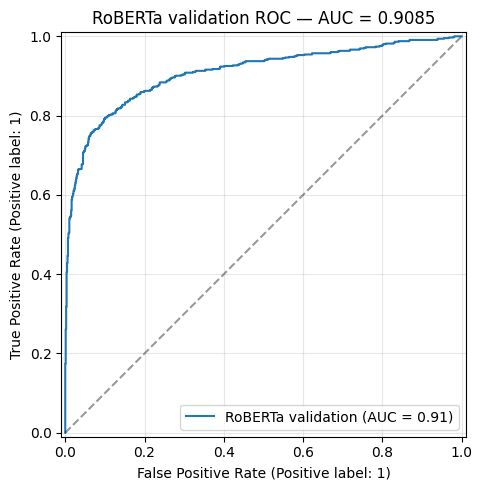

In [6]:
roberta = build_roberta()
roberta.fit(
    list(X_train_np),
    y_train_np,
    validation_data=(list(X_val_np), y_val_np),
    batch_size=ROBERTA_BS,
    epochs=ROBERTA_EPOCHS,
    class_weight=ROBERTA_CLASS_WEIGHT,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=1,
        restore_best_weights=True,
    )],
    verbose=1,
)

roberta_val_probs = softmax2(roberta.predict(list(X_val_np), batch_size=ROBERTA_BS * 2, verbose=0))
roberta_test_probs_validation_model = softmax2(roberta.predict(list(X_test_np), batch_size=ROBERTA_BS * 2, verbose=0))

f1, t = best_threshold_f1(y_val_np, roberta_val_probs)
print(f"RoBERTa validation best F1: {f1:.4f} @ threshold={t:.3f}")
plot_roc(y_val_np, roberta_val_probs, "RoBERTa validation")

del roberta
cleanup_memory()


## 5. Train one final RoBERTa on all labels for stronger test predictions

This is still much cheaper than full 5-fold RoBERTa. It has no validation predictions, so the validation model is still used for threshold/weight tuning. The final test probability is blended with the validation-model test probability.

For maximum leaderboard F1, this is enabled by default.


In [7]:
TRAIN_FINAL_ROBERTA_ON_FULL_DATA = True
FINAL_ROBERTA_TEST_WEIGHT = 0.50  # 0.50 = average validation-split RoBERTa and full-data RoBERTa test probs

if TRAIN_FINAL_ROBERTA_ON_FULL_DATA:
    all_texts = df_train["text"].astype(str).values
    all_y = df_train["target"].astype(int).values

    roberta_full = build_roberta()
    roberta_full.fit(
        list(all_texts),
        all_y,
        batch_size=ROBERTA_BS,
        epochs=ROBERTA_EPOCHS,
        class_weight=ROBERTA_CLASS_WEIGHT,
        verbose=1,
    )
    roberta_test_probs_full_model = softmax2(
        roberta_full.predict(list(X_test_np), batch_size=ROBERTA_BS * 2, verbose=0)
    )
    roberta_test_probs = (
        (1.0 - FINAL_ROBERTA_TEST_WEIGHT) * roberta_test_probs_validation_model
        + FINAL_ROBERTA_TEST_WEIGHT * roberta_test_probs_full_model
    )
    del roberta_full
    cleanup_memory()
else:
    roberta_test_probs = roberta_test_probs_validation_model.copy()

print("RoBERTa test probabilities ready.")


/Users/josemarialopes/.pyenv/versions/3.13.13/lib/python3.13/site-packages/keras/src/backend/torch/core.py:630: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return inputs[slices]


Epoch 1/3
238/238 ━━━━━━━━━━━━━━━━━━━━ 602s 3s/step - accuracy: 0.7507 - loss: 0.6041
Epoch 2/3
238/238 ━━━━━━━━━━━━━━━━━━━━ 638s 3s/step - accuracy: 0.8453 - loss: 0.4404
Epoch 3/3
238/238 ━━━━━━━━━━━━━━━━━━━━ 733s 3s/step - accuracy: 0.8705 - loss: 0.3768
RoBERTa test probabilities ready.


## 6. Ensemble grid search on the shared validation set

This keeps the exact objective aligned with your goal: maximize validation F1 by tuning both weights and decision threshold.


Individual validation scores:
RoBERTa                F1=0.8238 @ threshold=0.750
Transformer blended    F1=0.7830 @ threshold=0.480
LogReg blended         F1=0.7786 @ threshold=0.485

Best weighted ensemble:
{
  "type": "weighted_soft_vote",
  "f1": 0.8321513002364066,
  "threshold": 0.645,
  "weights": {
    "roberta": 0.675,
    "transformer": 0.125,
    "logreg": 0.19999999999999996
  }
}

Selected validation F1: 0.8322


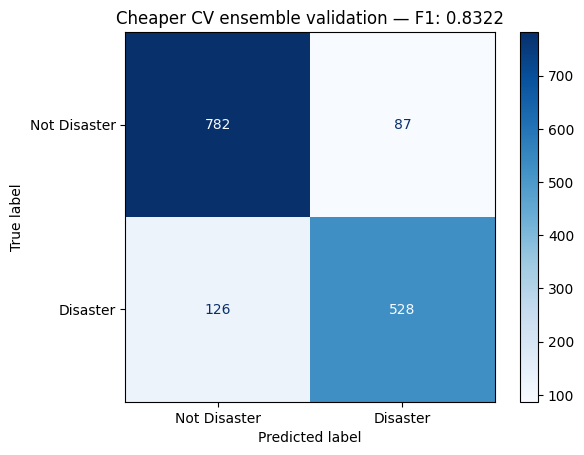

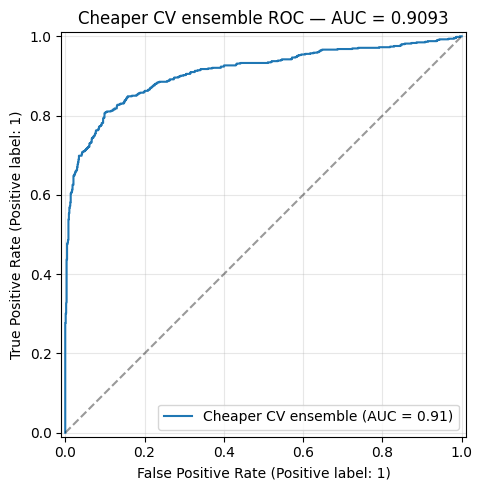

0.9093284488128293

In [8]:
print("Individual validation scores:")
for name, probs in {
    "RoBERTa": roberta_val_probs,
    "Transformer blended": transformer_val_probs,
    "LogReg blended": logreg_val_probs,
}.items():
    f1, t = best_threshold_f1(y_val_np, probs)
    print(f"{name:22s} F1={f1:.4f} @ threshold={t:.3f}")

prob_dict = {
    "roberta": roberta_val_probs,
    "transformer": transformer_val_probs,
    "logreg": logreg_val_probs,
}
weighted_best = search_weighted_ensemble(
    y_val_np,
    prob_dict,
    weight_step=0.025,
    threshold_low=0.20,
    threshold_high=0.80,
    threshold_steps=121,
)
print("\nBest weighted ensemble:")
print(json.dumps(weighted_best, indent=2))

combined_val = (
    weighted_best["weights"]["roberta"] * roberta_val_probs
    + weighted_best["weights"]["transformer"] * transformer_val_probs
    + weighted_best["weights"]["logreg"] * logreg_val_probs
)
combined_test = (
    weighted_best["weights"]["roberta"] * roberta_test_probs
    + weighted_best["weights"]["transformer"] * transformer_test_probs
    + weighted_best["weights"]["logreg"] * logreg_test_probs
)
threshold = weighted_best["threshold"]

print(f"\nSelected validation F1: {f1_score(y_val_np, (combined_val >= threshold).astype(int), zero_division=0):.4f}")
display_confusion_matrix(y_val_np, combined_val, "Cheaper CV ensemble validation", threshold=threshold)
plot_roc(y_val_np, combined_val, "Cheaper CV ensemble")


## 7. Generate final submission


In [9]:
sub = pd.DataFrame({
    "id": df_test["id"],
    "target": (combined_test >= threshold).astype(int),
})

submission_path = os.path.join(SUBMISSION_DIR, "submission_cheaper_cv_ensemble.csv")
sub.to_csv(submission_path, index=False)

params_path = os.path.join(SUBMISSION_DIR, "submission_cheaper_cv_ensemble_params.json")
params_to_save = {
    "ensemble": weighted_best,
    "logreg_blend": logreg_blend,
    "transformer_blend": transformer_blend,
    "train_final_roberta_on_full_data": TRAIN_FINAL_ROBERTA_ON_FULL_DATA,
    "final_roberta_test_weight": FINAL_ROBERTA_TEST_WEIGHT,
}
with open(params_path, "w") as f:
    json.dump(params_to_save, f, indent=2)

pred_path = os.path.join(SUBMISSION_DIR, "cheaper_cv_ensemble_predictions.npz")
np.savez(
    pred_path,
    logreg_val_probs=logreg_val_probs,
    logreg_test_probs=logreg_test_probs,
    transformer_val_probs=transformer_val_probs,
    transformer_test_probs=transformer_test_probs,
    roberta_val_probs=roberta_val_probs,
    roberta_test_probs=roberta_test_probs,
    combined_val=combined_val,
    combined_test=combined_test,
    y_val=y_val_np,
)

print("Saved:", submission_path)
print("Saved:", params_path)
print("Saved:", pred_path)
print(sub["target"].value_counts())
sub.head()


Saved: ../submission-files/submission_cheaper_cv_ensemble.csv
Saved: ../submission-files/submission_cheaper_cv_ensemble_params.json
Saved: ../submission-files/cheaper_cv_ensemble_predictions.npz
target
0    2059
1    1204
Name: count, dtype: int64


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
